In [1]:
import os
import itertools
from collections import defaultdict

In [2]:
def load_documents(path="data"):
    
    docs = {}
    
    for i in range(1,5):
        with open(os.path.join(path,f"D{i}.txt"),"r") as f:
            docs[f"D{i}"] = f.read().strip()
            
    return docs

docs = load_documents()

print("Loaded Documents\n")

for name,text in docs.items():
    print(name,"->",text)

Loaded Documents

D1 -> apple ceo tim cook is spending some time in canada this week and yesterday he attended a hockey game and visited the eaton centre apple store in toronto cook today stopped by the offices of canadian ecommerce platform shopify where he spoke to the financial post about augmented reality apps and the homepod on the topic of the homepod cook said that apples deep integration between hardware and software will help to differentiate the smart speaker from competing products like amazons alexa and the google home competition makes all of us better and i welcome it cook said but if you are both trying to license something and compete with your licensees this is a difficult model and it remains to be seen if it can be successful or not cook also said a quality very immersive audio experience was one thing missing from the smart speaker market which apple is aiming to fix music deserves that kind of quality as opposed to some kind of squeaky sound he said the homepod whi

In [3]:
print("Document Statistics\n")

for name,text in docs.items():
    
    print("Document:",name)
    print("Length:",len(text))
    print("Words:",len(text.split()))
    print("Preview:",text[:60])
    print("-"*40)

Document Statistics

Document: D1
Length: 1749
Words: 303
Preview: apple ceo tim cook is spending some time in canada this week
----------------------------------------
Document: D2
Length: 1747
Words: 303
Preview: apple ceo tim cook is spending some time in canada this week
----------------------------------------
Document: D3
Length: 2132
Words: 380
Preview: as part of his one day tour of canada yesterday tim cook off
----------------------------------------
Document: D4
Length: 1435
Words: 255
Preview: president trump who warned as a candidate about the false so
----------------------------------------


In [4]:
def char_kgrams(text,k):
    
    grams=set()
    
    for i in range(len(text)-k+1):
        grams.add(text[i:i+k])
        
    return grams

In [5]:
def word_kgrams(text,k):
    
    words=text.split()
    
    grams=set()
    
    for i in range(len(words)-k+1):
        grams.add(tuple(words[i:i+k]))
        
    return grams

In [6]:
test="data mining course"

print("Character 2-grams")
print(char_kgrams(test,2))

print("\nCharacter 3-grams")
print(char_kgrams(test,3))

print("\nWord 2-grams")
print(word_kgrams(test,2))

Character 2-grams
{' m', 'mi', 'ng', ' c', 'g ', 'ni', 'co', 'ur', 'se', 'ta', 'da', 'at', 'rs', 'a ', 'ou', 'in'}

Character 3-grams
{' co', 'ata', 'ng ', 'g c', 'min', 'a m', 'cou', 'urs', 'nin', 'ing', 'ini', 'our', ' mi', 'ta ', 'dat', 'rse'}

Word 2-grams
{('mining', 'course'), ('data', 'mining')}


In [7]:
kgrams = {}

for name,text in docs.items():
    
    kgrams[name] = {
        "char2": char_kgrams(text,2),
        "char3": char_kgrams(text,3),
        "word2": word_kgrams(text,2)
    }

In [8]:
print("Number of k-grams in each document\n")

for doc in docs:
    
    print("Document:",doc)
    
    print("char2:",len(kgrams[doc]["char2"]))
    print("char3:",len(kgrams[doc]["char3"]))
    print("word2:",len(kgrams[doc]["word2"]))
    
    print("-"*30)

Number of k-grams in each document

Document: D1
char2: 263
char3: 765
word2: 279
------------------------------
Document: D2
char2: 262
char3: 762
word2: 278
------------------------------
Document: D3
char2: 269
char3: 828
word2: 337
------------------------------
Document: D4
char2: 255
char3: 698
word2: 232
------------------------------


In [9]:
for doc in docs:
    
    print("\nDocument:",doc)
    
    print("\nCharacter 2-grams:")
    print(sorted(list(kgrams[doc]["char2"]))[:20])
    
    print("\nCharacter 3-grams:")
    print(sorted(list(kgrams[doc]["char3"]))[:20])
    
    print("\nWord 2-grams:")
    print(list(kgrams[doc]["word2"])[:10])


Document: D1

Character 2-grams:
[' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h', ' i', ' k', ' l', ' m', ' n', ' o', ' p', ' q', ' r', ' s', ' t', ' u']

Character 3-grams:
[' a ', ' ab', ' ac', ' ad', ' ai', ' al', ' am', ' an', ' ap', ' ar', ' as', ' at', ' au', ' aw', ' be', ' bo', ' bu', ' by', ' ca', ' ce']

Word 2-grams:
[('with', 'your'), ('that', 'apples'), ('hockey', 'game'), ('read', 'over'), ('post', 'about'), ('with', 'the'), ('best', 'possible'), ('details', 'on'), ('topic', 'of'), ('his', 'interview')]

Document: D2

Character 2-grams:
[' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h', ' i', ' k', ' l', ' m', ' n', ' o', ' p', ' q', ' r', ' s', ' t', ' u']

Character 3-grams:
[' a ', ' ab', ' ac', ' ad', ' ai', ' al', ' am', ' an', ' ap', ' ar', ' as', ' at', ' au', ' aw', ' be', ' bu', ' by', ' ca', ' ce', ' co']

Word 2-grams:
[('with', 'your'), ('that', 'apples'), ('hockey', 'game'), ('read', 'over'), ('post', 'about'), ('with', 'the'), ('best', 'possible'), ('details'

In [10]:
def jaccard(a,b):
    
    intersection = len(a & b)
    union = len(a | b)
    
    return intersection/union

In [11]:
A = {1,2,3,4}
B = {3,4,5}

print("Example sets")

print("A:",A)
print("B:",B)

print("\nIntersection:",A&B)
print("Union:",A|B)

print("\nJaccard similarity:",jaccard(A,B))

Example sets
A: {1, 2, 3, 4}
B: {3, 4, 5}

Intersection: {3, 4}
Union: {1, 2, 3, 4, 5}

Jaccard similarity: 0.4


In [12]:
pairs = list(itertools.combinations(docs.keys(),2))

print("Document pairs\n")

for p in pairs:
    print(p)

Document pairs

('D1', 'D2')
('D1', 'D3')
('D1', 'D4')
('D2', 'D3')
('D2', 'D4')
('D3', 'D4')


In [13]:
results = defaultdict(dict)

for gram_type in ["char2","char3","word2"]:
    
    print("\n============================")
    print("Gram Type:",gram_type)
    print("============================")
    
    for d1,d2 in pairs:
        
        sim = jaccard(
            kgrams[d1][gram_type],
            kgrams[d2][gram_type]
        )
        
        results[gram_type][(d1,d2)] = sim
        
        print(d1,"vs",d2,"=",round(sim,4))


Gram Type: char2
D1 vs D2 = 0.9811
D1 vs D3 = 0.8157
D1 vs D4 = 0.6444
D2 vs D3 = 0.8
D2 vs D4 = 0.6413
D3 vs D4 = 0.653

Gram Type: char3
D1 vs D2 = 0.978
D1 vs D3 = 0.5804
D1 vs D4 = 0.3051
D2 vs D3 = 0.568
D2 vs D4 = 0.3059
D3 vs D4 = 0.3121

Gram Type: word2
D1 vs D2 = 0.9408
D1 vs D3 = 0.1823
D1 vs D4 = 0.0302
D2 vs D3 = 0.1737
D2 vs D4 = 0.0303
D3 vs D4 = 0.0161


In [14]:
print("\nSummary Table\n")

for gram_type in results:
    
    print("\n",gram_type)
    
    for pair,val in results[gram_type].items():
        print(pair,"->",round(val,4))


Summary Table


 char2
('D1', 'D2') -> 0.9811
('D1', 'D3') -> 0.8157
('D1', 'D4') -> 0.6444
('D2', 'D3') -> 0.8
('D2', 'D4') -> 0.6413
('D3', 'D4') -> 0.653

 char3
('D1', 'D2') -> 0.978
('D1', 'D3') -> 0.5804
('D1', 'D4') -> 0.3051
('D2', 'D3') -> 0.568
('D2', 'D4') -> 0.3059
('D3', 'D4') -> 0.3121

 word2
('D1', 'D2') -> 0.9408
('D1', 'D3') -> 0.1823
('D1', 'D4') -> 0.0302
('D2', 'D3') -> 0.1737
('D2', 'D4') -> 0.0303
('D3', 'D4') -> 0.0161


In [15]:
all_char3=set()

for doc in kgrams:
    
    all_char3 |= kgrams[doc]["char3"]

print("Total unique 3-grams in corpus:",len(all_char3))

Total unique 3-grams in corpus: 1301


In [16]:
shingle_to_id={}

for i,shingle in enumerate(all_char3):
    shingle_to_id[shingle]=i

print("Total indexed shingles:",len(shingle_to_id))

print("\nExample mapping:")
for i,(k,v) in enumerate(shingle_to_id.items()):
    
    print(k,"->",v)
    
    if i==10:
        break

Total indexed shingles: 1301

Example mapping:
lif -> 0
s d -> 1
woo -> 2
rst -> 3
tol -> 4
l o -> 5
nse -> 6
ina -> 7
e s -> 8
be  -> 9
inv -> 10


In [17]:
doc_shingles={}

for doc in kgrams:
    
    ids=set()
    
    for g in kgrams[doc]["char3"]:
        ids.add(shingle_to_id[g])
        
    doc_shingles[doc]=ids

In [18]:
for doc in doc_shingles:
    
    print("\nDocument:",doc)
    
    print("Number of shingles:",len(doc_shingles[doc]))
    
    print("Example shingles:")
    print(list(doc_shingles[doc])[:15])


Document: D1
Number of shingles: 765
Example shingles:
[0, 1, 2, 5, 6, 7, 8, 9, 11, 14, 18, 22, 24, 25, 26]

Document: D2
Number of shingles: 762
Example shingles:
[0, 1, 2, 5, 6, 7, 8, 9, 11, 14, 18, 22, 24, 25, 26]

Document: D3
Number of shingles: 828
Example shingles:
[0, 1, 5, 6, 7, 8, 9, 17, 18, 23, 24, 25, 26, 27, 28]

Document: D4
Number of shingles: 698
Example shingles:
[3, 4, 7, 8, 9, 10, 11, 12, 13, 15, 16, 19, 20, 21, 24]


In [19]:
true_jaccard=jaccard(
    kgrams["D1"]["char3"],
    kgrams["D2"]["char3"]
)

print("True Jaccard similarity (D1 vs D2):",true_jaccard)

True Jaccard similarity (D1 vs D2): 0.977979274611399


In [20]:
import random

def generate_hash_functions(t,m):
    
    hash_funcs=[]
    
    for _ in range(t):
        
        a=random.randint(1,m-1)
        b=random.randint(0,m-1)
        
        hash_funcs.append((a,b))
        
    return hash_funcs

In [21]:
def compute_minhash_signature(shingles,hash_funcs,m):
    
    signature=[]
    
    for a,b in hash_funcs:
        
        min_val=float("inf")
        
        for shingle in shingles:
            
            h=(a*shingle + b) % m
            
            if h < min_val:
                min_val=h
        
        signature.append(min_val)
    
    return signature

In [22]:
def minhash_similarity(sig1,sig2):
    
    matches=0
    
    for i in range(len(sig1)):
        
        if sig1[i]==sig2[i]:
            matches+=1
            
    return matches/len(sig1)

In [23]:
t_values=[20,60,150,300,600]

m=100000

results={}

for t in t_values:
    
    print("\n=================================")
    print("Number of hash functions:",t)
    print("=================================")
    
    hash_funcs=generate_hash_functions(t,m)
    
    sig1=compute_minhash_signature(
        doc_shingles["D1"],
        hash_funcs,
        m
    )
    
    sig2=compute_minhash_signature(
        doc_shingles["D2"],
        hash_funcs,
        m
    )
    
    approx=minhash_similarity(sig1,sig2)
    
    results[t]=approx
    
    print("Approximate Jaccard:",approx)
    print("True Jaccard:",true_jaccard)
    print("Error:",abs(approx-true_jaccard))


Number of hash functions: 20
Approximate Jaccard: 1.0
True Jaccard: 0.977979274611399
Error: 0.022020725388601003

Number of hash functions: 60
Approximate Jaccard: 0.9833333333333333
True Jaccard: 0.977979274611399
Error: 0.005354058721934285

Number of hash functions: 150
Approximate Jaccard: 0.9533333333333334
True Jaccard: 0.977979274611399
Error: 0.02464594127806563

Number of hash functions: 300
Approximate Jaccard: 0.9866666666666667
True Jaccard: 0.977979274611399
Error: 0.008687392055267695

Number of hash functions: 600
Approximate Jaccard: 0.97
True Jaccard: 0.977979274611399
Error: 0.007979274611399023


In [24]:
print("\nSummary of experiments\n")

for t,val in results.items():
    
    print("t =",t,
          "| Estimated Jaccard =",round(val,4),
          "| True =",round(true_jaccard,4))


Summary of experiments

t = 20 | Estimated Jaccard = 1.0 | True = 0.978
t = 60 | Estimated Jaccard = 0.9833 | True = 0.978
t = 150 | Estimated Jaccard = 0.9533 | True = 0.978
t = 300 | Estimated Jaccard = 0.9867 | True = 0.978
t = 600 | Estimated Jaccard = 0.97 | True = 0.978


In [25]:
print("Variance experiment with t = 100\n")

for i in range(5):
    
    hash_funcs=generate_hash_functions(100,100000)
    
    sig1=compute_minhash_signature(doc_shingles["D1"],hash_funcs,100000)
    sig2=compute_minhash_signature(doc_shingles["D2"],hash_funcs,100000)
    
    approx=minhash_similarity(sig1,sig2)
    
    print("Run",i+1,"->",approx)

Variance experiment with t = 100

Run 1 -> 0.98
Run 2 -> 0.98
Run 3 -> 0.99
Run 4 -> 0.96
Run 5 -> 0.93


In [26]:
t = 160
m = 100000

hash_funcs_160 = generate_hash_functions(t,m)

print("Number of hash functions:",len(hash_funcs_160))

Number of hash functions: 160


In [27]:
signatures={}

for doc in doc_shingles:
    
    sig = compute_minhash_signature(
        doc_shingles[doc],
        hash_funcs_160,
        m
    )
    
    signatures[doc]=sig

In [28]:
for doc in signatures:
    
    print("\nDocument:",doc)
    
    print("Signature length:",len(signatures[doc]))
    
    print("First 20 values:")
    print(signatures[doc][:20])


Document: D1
Signature length: 160
First 20 values:
[56, 25, 253, 76, 419, 69, 313, 272, 244, 30, 1, 30, 341, 107, 28, 22, 176, 25, 69, 79]

Document: D2
Signature length: 160
First 20 values:
[56, 25, 253, 76, 419, 69, 313, 272, 244, 30, 1, 30, 341, 107, 28, 22, 176, 25, 69, 79]

Document: D3
Signature length: 160
First 20 values:
[56, 29, 253, 76, 314, 69, 173, 12, 184, 70, 1, 54, 11, 10, 28, 9, 256, 25, 69, 174]

Document: D4
Signature length: 160
First 20 values:
[56, 125, 125, 131, 81, 69, 20, 12, 164, 347, 1, 6, 11, 107, 28, 9, 11, 25, 69, 79]


In [29]:
true_similarities={}

for d1,d2 in pairs:
    
    sim=jaccard(
        kgrams[d1]["char3"],
        kgrams[d2]["char3"]
    )
    
    true_similarities[(d1,d2)]=sim

print("True similarities\n")

for k,v in true_similarities.items():
    print(k,"->",round(v,4))

True similarities

('D1', 'D2') -> 0.978
('D1', 'D3') -> 0.5804
('D1', 'D4') -> 0.3051
('D2', 'D3') -> 0.568
('D2', 'D4') -> 0.3059
('D3', 'D4') -> 0.3121


In [30]:
def lsh_probability(s,r,b):
    
    return 1 - (1 - s**r)**b

In [31]:
candidates = [
    (2,80),
    (4,40),
    (5,32),
    (8,20),
    (10,16),
    (16,10),
    (20,8)
]

print("Possible (r,b) combinations:\n")

for r,b in candidates:
    print("r =",r," b =",b," product =",r*b)

Possible (r,b) combinations:

r = 2  b = 80  product = 160
r = 4  b = 40  product = 160
r = 5  b = 32  product = 160
r = 8  b = 20  product = 160
r = 10  b = 16  product = 160
r = 16  b = 10  product = 160
r = 20  b = 8  product = 160


In [32]:
threshold = 0.7

print("Probability at threshold s=0.7\n")

for r,b in candidates:
    
    prob = lsh_probability(threshold,r,b)
    
    print("r =",r,
          "b =",b,
          "-> probability =",round(prob,4))

Probability at threshold s=0.7

r = 2 b = 80 -> probability = 1.0
r = 4 b = 40 -> probability = 1.0
r = 5 b = 32 -> probability = 0.9972
r = 8 b = 20 -> probability = 0.695
r = 10 b = 16 -> probability = 0.3677
r = 16 b = 10 -> probability = 0.0327
r = 20 b = 8 -> probability = 0.0064


In [33]:
r = 8
b = 20

print("Chosen parameters")
print("r =",r)
print("b =",b)
print("r*b =",r*b)

Chosen parameters
r = 8
b = 20
r*b = 160


In [34]:
probabilities={}

print("LSH detection probability\n")

for pair,s in true_similarities.items():
    
    prob=lsh_probability(s,r,b)
    
    probabilities[pair]=prob
    
    print(pair,
          "| similarity =",round(s,4),
          "| candidate probability =",round(prob,4))

LSH detection probability

('D1', 'D2') | similarity = 0.978 | candidate probability = 1.0
('D1', 'D3') | similarity = 0.5804 | candidate probability = 0.2282
('D1', 'D4') | similarity = 0.3051 | candidate probability = 0.0015
('D2', 'D3') | similarity = 0.568 | candidate probability = 0.1959
('D2', 'D4') | similarity = 0.3059 | candidate probability = 0.0015
('D3', 'D4') | similarity = 0.3121 | candidate probability = 0.0018


In [35]:
print("\nSummary Table\n")

for pair in probabilities:
    
    print(pair,
          "-> probability",
          round(probabilities[pair],4))


Summary Table

('D1', 'D2') -> probability 1.0
('D1', 'D3') -> probability 0.2282
('D1', 'D4') -> probability 0.0015
('D2', 'D3') -> probability 0.1959
('D2', 'D4') -> probability 0.0015
('D3', 'D4') -> probability 0.0018


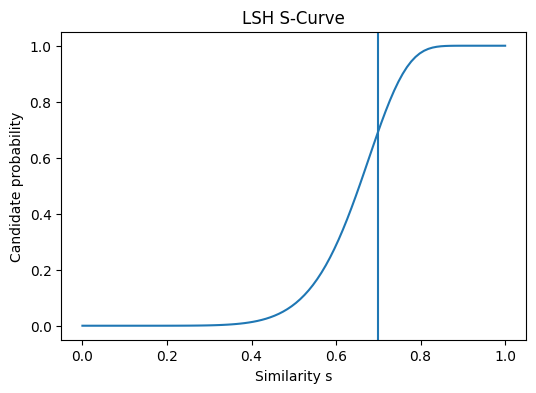

In [36]:
import numpy as np
import matplotlib.pyplot as plt


s_vals=np.linspace(0,1,100)

curve=[lsh_probability(s,r,b) for s in s_vals]

plt.figure(figsize=(6,4))

plt.plot(s_vals,curve)

plt.axvline(0.7)

plt.xlabel("Similarity s")
plt.ylabel("Candidate probability")
plt.title("LSH S-Curve")

plt.show()

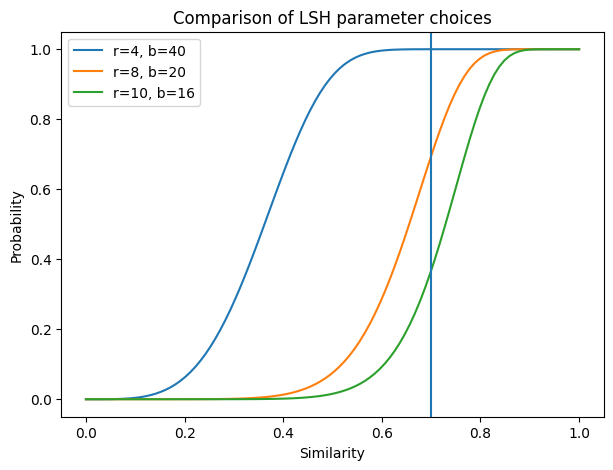

In [37]:
plt.figure(figsize=(7,5))

for r_test,b_test in [(4,40),(8,20),(10,16)]:
    
    curve=[lsh_probability(s,r_test,b_test) for s in s_vals]
    
    plt.plot(s_vals,curve,label=f"r={r_test}, b={b_test}")

plt.axvline(0.7)

plt.legend()

plt.xlabel("Similarity")
plt.ylabel("Probability")

plt.title("Comparison of LSH parameter choices")

plt.show()

In [38]:
import pandas as pd

data = pd.read_csv(
    "movielens/u.data",
    sep="\t",
    names=["user","movie","rating","timestamp"]
)

print("Dataset shape:",data.shape)

data.head()

Dataset shape: (100000, 4)


,user,movie,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [39]:
user_movies={}

for user,movie in zip(data["user"],data["movie"]):
    
    if user not in user_movies:
        user_movies[user]=set()
        
    user_movies[user].add(movie)

print("Number of users:",len(user_movies))

Number of users: 943


In [40]:
sizes=[len(v) for v in user_movies.values()]

print("Average movies per user:",sum(sizes)/len(sizes))
print("Minimum movies:",min(sizes))
print("Maximum movies:",max(sizes))

Average movies per user: 106.04453870625663
Minimum movies: 20
Maximum movies: 737


In [41]:
def jaccard_users(u1,u2):
    
    a=user_movies[u1]
    b=user_movies[u2]
    
    return len(a & b)/len(a | b)

In [42]:
users=list(user_movies.keys())

print("Total users:",len(users))

user_pairs=list(itertools.combinations(users,2))

print("Total pairs:",len(user_pairs))

Total users: 943
Total pairs: 444153


In [43]:
exact_pairs=set()

print("Computing exact similarities...\n")

for u1,u2 in user_pairs:
    
    sim=jaccard_users(u1,u2)
    
    if sim >= 0.5:
        exact_pairs.add((u1,u2))

print("Number of pairs with similarity >= 0.5:",len(exact_pairs))

Computing exact similarities...

Number of pairs with similarity >= 0.5: 10


In [44]:
all_movies=set(data["movie"])

movie_to_id={}

for i,m in enumerate(all_movies):
    movie_to_id[m]=i

print("Total movies:",len(movie_to_id))

Total movies: 1682


In [45]:
user_movie_ids={}

for user in user_movies:
    
    ids=set()
    
    for m in user_movies[user]:
        ids.add(movie_to_id[m])
        
    user_movie_ids[user]=ids

In [46]:
def compute_user_signature(movie_ids,hash_funcs,m):
    
    sig=[]
    
    for a,b in hash_funcs:
        
        min_val=float("inf")
        
        for movie in movie_ids:
            
            h=(a*movie+b)%m
            
            if h<min_val:
                min_val=h
                
        sig.append(min_val)
        
    return sig

In [47]:
def run_minhash_experiment(t):
    
    m=100000
    
    hash_funcs=generate_hash_functions(t,m)
    
    signatures={}
    
    for user in user_movie_ids:
        
        signatures[user]=compute_user_signature(
            user_movie_ids[user],
            hash_funcs,
            m
        )
    
    approx_pairs=set()
    
    for u1,u2 in user_pairs:
        
        sim=minhash_similarity(
            signatures[u1],
            signatures[u2]
        )
        
        if sim>=0.5:
            approx_pairs.add((u1,u2))
    
    fp=len(approx_pairs - exact_pairs)
    
    fn=len(exact_pairs - approx_pairs)
    
    return fp,fn

In [48]:
t_values=[50,100,200]

results={}

for t in t_values:
    
    fps=[]
    fns=[]
    
    print("\nRunning experiment for t =",t)
    
    for i in range(5):
        
        fp,fn=run_minhash_experiment(t)
        
        fps.append(fp)
        fns.append(fn)
        
        print("Run",i+1,"FP:",fp,"FN:",fn)
    
    results[t]=(
        sum(fps)/5,
        sum(fns)/5
    )


Running experiment for t = 50


Run 1 FP: 40 FN: 4
Run 2 FP: 48 FN: 2
Run 3 FP: 61 FN: 1
Run 4 FP: 278 FN: 4
Run 5 FP: 132 FN: 2

Running experiment for t = 100
Run 1 FP: 68 FN: 2
Run 2 FP: 24 FN: 1
Run 3 FP: 29 FN: 2
Run 4 FP: 32 FN: 3
Run 5 FP: 24 FN: 0

Running experiment for t = 200
Run 1 FP: 8 FN: 0
Run 2 FP: 4 FN: 3
Run 3 FP: 10 FN: 2
Run 4 FP: 8 FN: 2
Run 5 FP: 7 FN: 2


In [49]:
def band_hash(band):
    
    return hash(tuple(band))

In [50]:
def lsh_candidates(signatures, r, b):
    
    buckets = {}
    
    for band in range(b):
        
        buckets.clear()
        
        start = band * r
        end = start + r
        
        for user in signatures:
            
            band_sig = signatures[user][start:end]
            
            h = band_hash(band_sig)
            
            if h not in buckets:
                buckets[h] = []
            
            buckets[h].append(user)
        
        for bucket in buckets.values():
            
            if len(bucket) > 1:
                
                for pair in itertools.combinations(bucket,2):
                    yield pair

In [51]:
def run_lsh_experiment(t,r,b):
    
    m=100000
    
    hash_funcs=generate_hash_functions(t,m)
    
    signatures={}
    
    for user in user_movie_ids:
        
        signatures[user]=compute_user_signature(
            user_movie_ids[user],
            hash_funcs,
            m
        )
    
    candidate_pairs=set(lsh_candidates(signatures,r,b))
    
    predicted=set()
    
    for u1,u2 in candidate_pairs:
        
        sim=jaccard_users(u1,u2)
        
        if sim >= 0.6:
            predicted.add((u1,u2))
    
    true_pairs=set()
    
    for u1,u2 in user_pairs:
        
        sim=jaccard_users(u1,u2)
        
        if sim >= 0.6:
            true_pairs.add((u1,u2))
    
    fp=len(predicted - true_pairs)
    fn=len(true_pairs - predicted)
    
    return fp,fn

In [52]:
configs = [
    (50,5,10),
    (100,5,20),
    (200,5,40),
    (200,10,20)
]

configs

[(50, 5, 10), (100, 5, 20), (200, 5, 40), (200, 10, 20)]

In [53]:
results_lsh={}

for t,r,b in configs:
    
    fps=[]
    fns=[]
    
    print("\nConfiguration")
    print("t =",t,"r =",r,"b =",b)
    
    for i in range(5):
        
        fp,fn = run_lsh_experiment(t,r,b)
        
        fps.append(fp)
        fns.append(fn)
        
        print("Run",i+1,"FP:",fp,"FN:",fn)
    
    results_lsh[(t,r,b)] = (
        sum(fps)/5,
        sum(fns)/5
    )


Configuration
t = 50 r = 5 b = 10


Run 1 FP: 0 FN: 1
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 1
Run 4 FP: 0 FN: 1
Run 5 FP: 0 FN: 1

Configuration
t = 100 r = 5 b = 20
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 1
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0

Configuration
t = 200 r = 5 b = 40
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0

Configuration
t = 200 r = 10 b = 20
Run 1 FP: 0 FN: 2
Run 2 FP: 0 FN: 2
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 1
Run 5 FP: 0 FN: 0


In [54]:
print("\nAverage False Positives and False Negatives\n")

for config,(fp,fn) in results_lsh.items():
    
    t,r,b=config
    
    print(
        "t=",t,
        "r=",r,
        "b=",b,
        "| Avg FP:",round(fp,2),
        "| Avg FN:",round(fn,2)
    )


Average False Positives and False Negatives

t= 50 r= 5 b= 10 | Avg FP: 0.0 | Avg FN: 0.8
t= 100 r= 5 b= 20 | Avg FP: 0.0 | Avg FN: 0.2
t= 200 r= 5 b= 40 | Avg FP: 0.0 | Avg FN: 0.0
t= 200 r= 10 b= 20 | Avg FP: 0.0 | Avg FN: 1.0


In [61]:
threshold = 0.8

pairs_08 = []

for u1, u2 in user_pairs:
    
    sim = jaccard_users(u1, u2)
    
    if sim >= threshold:
        pairs_08.append((u1,u2))

print("Pairs with similarity >= 0.8:", len(pairs_08))

Pairs with similarity >= 0.8: 1
